<a href="https://colab.research.google.com/github/gennigesludovic28-rgb/INSA-Projet-Drone/blob/main/laboratories/Lab-High_speed_multirotor/Frame/05a_FrameSizing-Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Frame selection (student version)
*Written by Marc Budinger (INSA Toulouse), Scott Delbecq (ISAE-SUPAERO) and Félix Pollet (ISAE-SUPAERO), Toulouse, France.*

## Mechanical and Aerodynamic Functions of a drone structure

The structure of a drone supports payloads (such as cameras, sensors and batteries) and distributes structural loads (such as weight, inertia and vibrations). For the purposes of this project, we will assume that the mechanical structure is primarily composed of carbon composite tubes. You can draw inspiration from formulas for the strength of materials (stress in beams under bending).

The drone structure also aims to minimise drag with streamlined shapes (e.g. tapered arms and enclosed fuselages) to reduce parasitic drag, and smooth surfaces to limit skin friction drag. Wing-like structures (for fixed-wing drones) generate lift. Blunt bodies (e.g. hemispheres or tubes) are dominated by pressure drag. Streamlined bodies (e.g. airfoils) are dominated by surface and lift-induced drag.


## Design graph

The following diagram represents the design graph of the frame selection.


```{figure} ./assets/design_graphs/DesignGraphs_airframe_student.svg
:name: design_graph_airframe_student
:align: center
:width: 50%

Airframe design graph
```

```{exercise}
:label: exercice_dg_frame

- Give the main sizing problems you are able to detect.
- Propose one or multiple solutions (which can request equation manipulation, addition of design variables, addition of constraints)
- Orientate the arrows
- Give equations order, inputs/outputs at each step of this part of sizing procedure

```


### Sizing code



```{exercise}
:label: exercice_dg_frame

Propose a sizing code for the frame

```


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Specifications
N_arm = 4.0  # [-] Number of arms
N_pro_arm = 1.0  # [-] Number of propellers per arm (1 or 2)

# Reference parameters for scaling laws
sigma_max = (
    280e6 / 4.0
)  # [Pa] Composite max stress (2 reduction for dynamic, 2 reduction for stress concentration)
rho_carbon = 1600.0  # [kg/m3] Volumic mass of carbon

# Assumptions
D_pro = 0.3  # [m] Propeller diameter
F_pro_to = 15.0  # [N] Thrust for one propeller during take off

# Design variables
E = 0.01 # [m] écart entre hélice
L_body = 0.2 # [m] Longueur drone
D_body = 0.14 # [m] Diamètre drone
D_out = 0.02 # [m] Epaisseur bras
H_arm = 0.04 # [m] Profondeur bras
k = 0.8 # Rapport des diamètres du bras D_in/D_arm
C = 0.3 # Coeff de forme drone
e = 0.8 # Efficacité d'Oswald
rho_air = 1.225 # [kg/m3]
v_160 = 160 / 3.6 # [m/s] vitesse à 160 km/h
v_300 = 300 / 3.6 # [m/s] vitesse à 300 km/h

La finesse maximale est de 7.62 atteinte à un angle de 24.7°


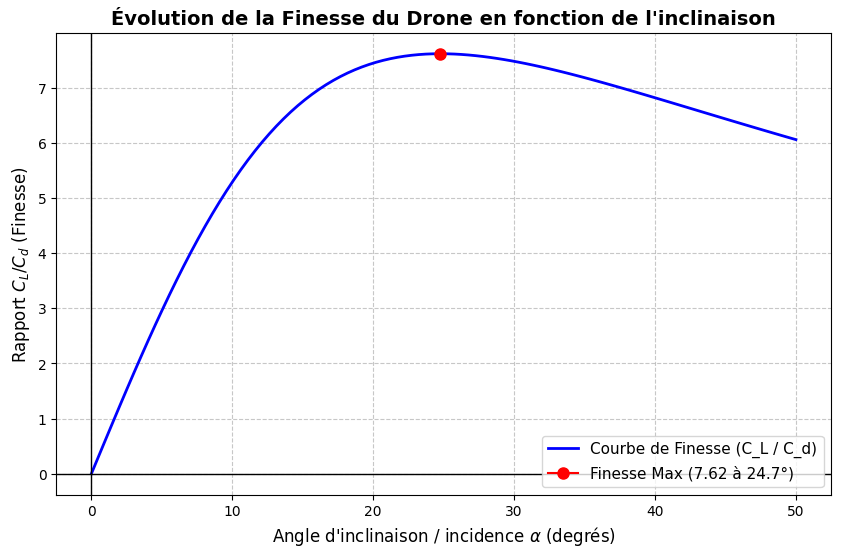

Moment vertical (Hélice) : 3.29 N.m
Moment horizontal (Vent) : 1.02 N.m
Moment total résultant   : 3.44 N.m

Contrainte sur le tube   : 73.3 MPa
Limite admissible        : 70.0 MPa
Ratio de contrainte      : 1.05
Le bras va casser, Il faut augmenter D_arm ou réduire le rapport k


In [ ]:
# Equations
L_arm = (D_pro + E) / (2 * np.sin(np.pi / N_arm))
D_arm = ((32 * F_pro_to * L_arm) / (sigma_max * np.pi * (1 - k**4)))**(1/3)

# Surface de référence
Sref_body = L_body * D_body
Sref_arm = 4 * L_arm * H_arm
Sref = Sref_body + Sref_arm

# Surface frontale
Sfr_body = (np.pi * (D_body**2)) / 4
Sfr_arm = 4 * L_arm * D_out
Sfr = Sfr_body + Sfr_arm

# Calcul de a (Coeff de trainée à O°)
a = C * (Sfr / Sref)

# Allongement effectif
AR = ((2 * L_arm + D_body)**2) / ((2 * L_arm + D_body) *  H_arm)

# Calcul k_L
k_L = (2 * np.pi) / (1 + (2 / AR)) * (np.pi / 180)

# Calcul de b (Trainée induite)
b = ((k_L**2) / (np.pi * e * AR))

# Calcul de la finesse
alpha = np.linspace(0, 50, 100)
C_L = k_L * alpha
C_d = a + b * (alpha**2)
finesse = C_L / C_d

# Recherche de l'angle optimal
index_max = np.argmax(finesse)
alpha_opt = alpha[index_max]
finesse_max = finesse[index_max]

C_L_opt = k_L * alpha_opt
C_d_opt = a + b * (alpha_opt**2)

print(f"La finesse maximale est de {finesse_max:.2f} atteinte à un angle de {alpha_opt:.1f}°")
plt.figure(figsize=(10, 6))
plt.plot(alpha, finesse, color='blue', linewidth=2, label='Courbe de Finesse (C_L / C_d)')
plt.plot(alpha_opt, finesse_max, marker='o', color='red', markersize=8, label=f'Finesse Max ({finesse_max:.2f} à {alpha_opt:.1f}°)')
plt.title("Évolution de la Finesse du Drone en fonction de l'inclinaison", fontsize=14, fontweight='bold')
plt.xlabel("Angle d'inclinaison / incidence $\\alpha$ (degrés)", fontsize=12)
plt.ylabel("Rapport $C_L / C_d$ (Finesse)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.legend(loc='lower right', fontsize=11)
plt.show()

# Scénario où le vent souflle à 150 km/h de face
# La finesse reste inchangée donc l'angle alpha optimal aussi car ils ne dépendent pas de la vitesse
v_vent = 150 / 3.6
v_relative = v_160 + v_vent
q_sv = 0.5 * rho_air * v_160**2 # pression dynamique sans vent
q_av = 0.5 * rho_air * v_relative**2 # pression dynamique avec vent

# Moment Horizontal (Aérodynamique sur le bras)
# Surface frontale de un bras (Longueur x Epaisseur)
Sfr_1arm = L_arm * D_arm
# Cd du bras sous gros vent, on prend le pire cas
C_arm = 1.0

# Moment de flexion
M_fz = F_pro_to * L_arm

# Moment quadratique
I_arm = (np.pi * (D_arm**4) * (1 - k**4)) / 64

# Force sur le bras au moment de son vol
Fd_arm = q_av * Sfr_1arm * C_arm

# Moment du à la force horizontale
M_h = Fd_arm * (L_arm / 2)

# Moment Total Résultant
M_tot = np.sqrt(M_fz**2 + M_h**2)

# Contrainte max à la base du bras
sigma_arm_v = (M_tot * (D_arm / 2)) / I_arm

sigma_ratio_v = sigma_arm_v / sigma_max

print(f"Moment vertical (Hélice) : {M_fz:.2f} N.m")
print(f"Moment horizontal (Vent) : {M_h:.2f} N.m")
print(f"Moment total résultant   : {M_tot:.2f} N.m\n")
print(f"Contrainte sur le tube   : {sigma_arm_v/1e6:.1f} MPa")
print(f"Limite admissible        : {sigma_max/1e6:.1f} MPa")
print(f"Ratio de contrainte      : {sigma_ratio_v:.2f}")

if sigma_ratio_v > 1.0:
    print("Le bras va casser, Il faut augmenter D_arm ou réduire le rapport k")
else:
    print("Le bras résistera à la rafale")

In [ ]:
%whos

Variable        Type       Data/Info
------------------------------------
AR              float64    14.460155108391488
C               float      0.3
C_L             ndarray    100: 100 elems, type `float64`, 800 bytes
C_L_opt         float64    2.3841147456504843
C_arm           float      1.0
C_d             ndarray    100: 100 elems, type `float64`, 800 bytes
C_d_opt         float64    0.31303124287619044
D_160           float64    23.887393437412495
D_300           float64    83.9791175534033
D_arm           float64    0.00932319048001776
D_av            float64    89.67103552091176
D_body          float      0.14
D_out           float      0.02
D_pro           float      0.3
E               float      0.01
F_pro_to        float      15.0
Fd_arm          float64    9.281875363870828
H_arm           float      0.04
I_arm           float64    2.189648866415864e-10
L               float64    181.93163853556499
L_arm           float64    0.21920310216782976
L_av            float64    

## Lift and drag evaluation

Based on the concept studied, propose a set of equations that can be used to evaluate the drag of your drone. Some concepts introduce wings or streamlined lifting surfaces. **NACA profiles** are standardized airfoil shapes developed by the **National Advisory Committee for Aeronautics** (NACA) to optimize lift, drag, and stall characteristics for aircraft wings. The **00xx notation** (e.g., NACA 0012) defines **symmetrical airfoils**: "00" indicates **no camber** (identical upper/lower surfaces), and "xx" specifies the **maximum thickness as a percentage of chord length** (e.g., 12% for NACA 0012).These profiles are widely used in **drones** for their predictable performance and simplicity in symmetric flight conditions.

Resources that may be of interest for understanding or as reference data:  
- Bruskiewich P., et al., Analysis and the Lift and Drag Forces on a Thin Wing. [Link](https://www.researchgate.net/publication/381829609_Dimensional_Analysis_and_the_Lift_and_Drag_Forces_on_a_Thin_Wing)
- Sogukpinar, H. (2017). Numerical simulation of 4-digit inclined NACA 00xx airfoils to find optimum angle of attack for airplane wing. [Link](https://web.archive.org/web/20180719205928id_/http://dergipark.gov.tr/download/article-file/298307)


In [ ]:
# Pour une vitesse de 160 km/h
L = 0.5 * rho_air * C_L_opt * Sref * v_160**2
D_160 = 0.5 * rho_air * C_d_opt * Sref * v_160**2

# Pour une vitesse de 300 km/h
D_300 = 0.5 * rho_air * C_d_opt * Sref * v_300**2

print(f"La portance est de {L:.2F} N")
print(f"La trainée à 160 km/h est de {D_160:.2F} N")
print(f"La trainée à 300 km/h est de {D_300:.2F} N \n")

# Pour une vitesse de 160 km/h avec des vents de 150 km/h
L_av = 0.5 * rho_air * C_L_opt * Sref * v_relative**2
D_av = 0.5 * rho_air * C_d_opt * Sref * v_relative**2

print(f"La portance avec du vent est de {L_av:.2F} N")
print(f"La trainée à 160 km/h avec du vent est de {D_av:.2F} N")

La portance est de 181.93 N
La trainée à 160 km/h est de 23.89 N
La trainée à 300 km/h est de 83.98 N 

La portance avec du vent est de 682.95 N
La trainée à 160 km/h avec du vent est de 89.67 N
